In [1]:
import numpy as np 
import os 
import glob 
import torch 
import random 
import pickle 
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps 
from skimage import measure, feature 
from scipy.spatial import distance 
from collections import defaultdict 
from sklearn.preprocessing import StandardScaler 
from tqdm.auto import tqdm, trange
from scipy.spatial.distance import cdist, pdist, squareform
import tifffile
import seaborn 
import copy

from scipy.ndimage import gaussian_filter  
import sys 
from stedfm import get_pretrained_model_v2 
sys.path.insert(0, "../")
from attribute_datasets import ALSDataset 
from wavelet import detect_spots

/opt/anaconda3/envs/phd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_svm():
    with open(f"./als-experiment/boundaries/MAE_SMALL_STED_als_svm_PSD95.pkl", "rb") as f:
        return pickle.load(f)

def load_boundary() -> np.ndarray:
    print(f"--- Loading boundary trained from MAE_SMALL_STED embeddings ---")
    data = np.load(f"../als-experiment/boundaries/MAE_SMALL_STED_als_boundary_PSD95.npz")
    boundary, intercept, norm = data["boundary"], data["intercept"], data["norm"]
    return boundary, intercept, norm

boundary, intercept, norm = load_boundary()

--- Loading boundary trained from MAE_SMALL_STED embeddings ---


In [3]:
latent_encoder, model_config = get_pretrained_model_v2(
    name="mae-lightning-small",
    weights="MAE_SMALL_STED",
    as_classifier=True
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_encoder.to(DEVICE)
latent_encoder.eval()

in_channels 1
--- mae-lightning-small | (https://s3.valeria.science/flclab-foundation-models/models/mae-small-sted.zip) Downloading from URL and extracting zip ---

Loading state_dict from /home-local/Frederic/baselines/mae-small_STED/pl_checkpoint-999.pth
--- Loaded model mae-lightning-small with weights MAE_SMALL_STED ---
--- Added linear probe to all frozen blocks ---


# Generated trajectories

In [4]:
def load_files(path, exclude=None, include=None):
    files = glob.glob(path)
    files.sort()
    files = [f for f in files if os.path.basename(f).split(".")[0].split("_")[-2] != "0"]
    # files = [os.path.basename(f) for f in files]
    trajectory_ids = [os.path.basename(f).split("_")[-4] for f in files]
    timestep_ids = [os.path.basename(f).split("_")[-2] for f in files]
    return np.array(files), np.array(trajectory_ids), np.array(timestep_ids)

path = "/home/frederic/flc-dataset/experiments/diffusion-experiments/als-experiment/PSD95/examples/raw-tif/*.tif"

files, trajectory_ids, timestep_ids = load_files(path)

In [5]:
PIXELSIZE = 0.015

def extract_features(img: np.ndarray, display: bool = False, mode: str = "gen"):
    mask = detect_spots(img, J_list=[3,4], scale_threshold=2.0)
    if display:
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].imshow(img, cmap="hot", vmin=0, vmax=1)
        axs[1].imshow(mask, cmap="gray")
        for ax in axs:
            ax.axis("off")
        plt.show() 

    mask_label, num_proteins = measure.label(mask, return_num=True)
    
    props = measure.regionprops(mask_label, intensity_image=img)

    # if mode != "real":
    #     filtered_props = []
    #     new_mask = copy.deepcopy(mask) 
    #     for p in props:
    #         if p.mean_intensity >= 0.09:
    #             filtered_props.append(p)
    #         else:
    #             lab = p.label
    #             new_mask[mask_label == lab] = 0 

        
    #     props = filtered_props 
    #     num_proteins = len(props)
    if num_proteins == 0:
        return np.array([])

    coordinates = np.array([p.weighted_centroid for p in props])
    distances = pdist(coordinates) * PIXELSIZE 
    distances = squareform(distances) 
    if len(distances) <= 1:
        nn_distances = [30.0]
    else:
        nn_distances = np.sort(distances, axis=1)[:, 1]
        nn_distances = np.clip(nn_distances, 0, 30.0)

    image_density = num_proteins / (img.shape[0] * img.shape[1] * PIXELSIZE**2)
    density_proteins = (np.sum(distances < 0.5, axis=1) - 1) / 1 # in number of proteins per um^2

    features = []
    counter = 0
    for prop, density, nn in zip(props, density_proteins, nn_distances):
        if np.isnan(nn):
            nn = 30.0

        # img = prop.intensity_image
        slc = prop.slice
        slc_img = img[slc]
        label = prop.image

        min_distance = int(0.08 / PIXELSIZE) // 2 + 1 # in pixels
        peaks = feature.peak_local_max(slc_img, min_distance=min_distance, exclude_border=False, labels=label)

        features.append([
            prop.area,
            prop.perimeter,
            prop.mean_intensity,
            prop.eccentricity,
            prop.solidity,
            density,
            len(peaks),
            num_proteins,
        ])

    return np.array(features)
    

def extract_trajectories(files, trajectory_ids, timestep_ids):
    print(f"[---] Processing {len(files)} files [---]")
    unique_trajectories = np.unique(trajectory_ids)

    num_trajectories = len(unique_trajectories) 
    all_trajectory_features = []
    
    for traj_id in unique_trajectories:
        indices = np.where(trajectory_ids == traj_id)
        trajectory_timesteps = timestep_ids[indices]
        trajectory_files = files[indices]
        trajectory_features = []
        for f in trajectory_files:
            img = tifffile.imread(f)
            features = extract_features(img)
            if features.size == 0:
                continue
            img_features = np.mean(features, axis=0)
            trajectory_features.append(img_features)
        
        trajectory_features = np.array(trajectory_features)
        all_trajectory_features.append(trajectory_features)

    all_trajectory_features = np.array(all_trajectory_features)
    return all_trajectory_features

all_trajectory_features = extract_trajectories(files, trajectory_ids, timestep_ids)

[---] Processing 228 files [---]


100%|██████████| 100/100 [00:00<00:00, 37206.64it/s]

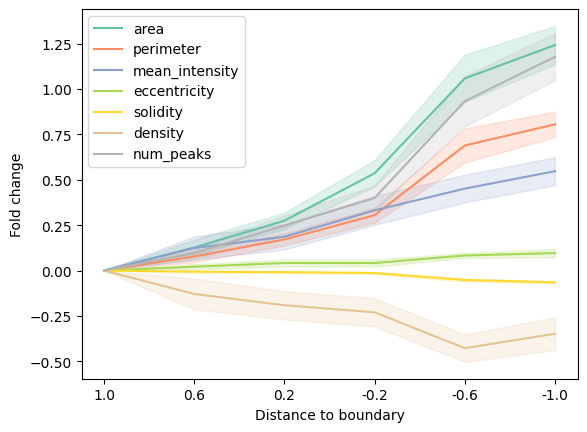

In [6]:
def get_confidence_interval(bootstrapped_trajectory):
    temp = np.take(bootstrapped_trajectory, indices, axis=axis)
    mean, cid, ciu = np.percentile(np.take(bootstrapped_trajectory, indices, axis=axis), [50, 5.0, 95], axis=0) 
    return mean, cid, ciu   

def bootstrap(trajectories, n=1000):
    out = []
    for _ in trange(n):
        indices = np.random.randint(0, len(trajectories), size=int(len(trajectories)*0.80))
        bootstrap_sample = trajectories[indices]
        mean = np.mean(bootstrap_sample, axis=0)
        out.append(mean)
    out = np.array(out)
    return out

def plot_trajectories(trajectory_features: np.ndarray, n=1000):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_trajectories, num_timesteps, num_features = trajectory_features.shape 
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    bootstrap_sample = bootstrap(trajectory_features, n=n)
    for feature_idx in range(num_features - 1):
        feature_data = bootstrap_sample[:, :, feature_idx]
        feature_data = (feature_data - feature_data[:, 0:1]) / feature_data[:, 0:1]
        mean, cid, ciu = np.mean(feature_data, axis=0), np.percentile(feature_data, 10.0, axis=0), np.percentile(feature_data, 90.0, axis=0)
        err = np.std(feature_data, axis=0)
        ax.plot(mean, c=cmap(feature_idx), label=feature_names[feature_idx])
        # ax.fill_between(np.arange(num_timesteps), cid, ciu, color=cmap(feature_idx), alpha=0.2)
        ax.fill_between(np.arange(num_timesteps), mean - err, mean + err, color=cmap(feature_idx), alpha=0.2)
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel("Fold change")
        ax.set_xticks(np.arange(num_timesteps))
        ax.set_xticklabels(["1.0", "0.6", "0.2", "-0.2", "-0.6", "-1.0"])
    ax.legend()
    plt.show()

        
            

plot_trajectories(all_trajectory_features, n=100)

## Random trajectories

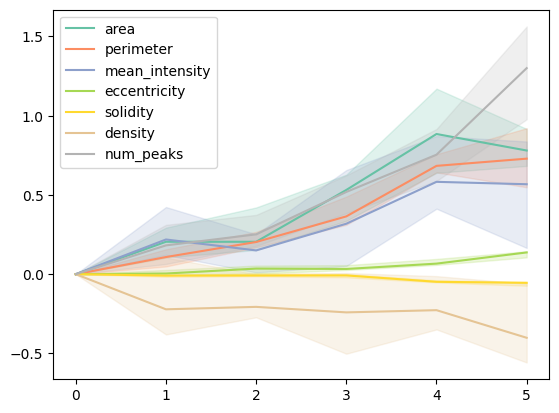

In [25]:
def plot_random_trajectories(trajectory_features: np.ndarray, n=1000):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    for feature_idx in range(trajectory_features.shape[-1] - 1):
        avg_out = []
        for _ in range(n):
            out = []
            for timestep in range(trajectory_features.shape[1]):
                random_trajectory_id = np.random.randint(0, len(trajectory_features))
                random_trajectory = trajectory_features[random_trajectory_id, timestep, feature_idx] 
                out.append(random_trajectory)
            out = np.array(out)
            avg_out.append(out) 
        avg_out = np.array(avg_out)
        avg_out = (avg_out - avg_out[:, 0:1]) / avg_out[:, 0:1]
        mean_out = np.median(avg_out, axis=0)
        # std_out = np.std(avg_out, axis=0)
        cid, ciu = np.percentile(avg_out, 40.0, axis=0), np.percentile(avg_out, 60.0, axis=0)

        ax.plot(mean_out, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(trajectory_features.shape[1]), cid, ciu, color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    plt.show()
            

   

plot_random_trajectories(all_trajectory_features, n=38)

# Real data

In [26]:
dataset_train = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-train.tar")
dataset_valid = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-valid.tar")
dataset_test = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-test.tar")
print(len(dataset_train))

def convert_label(div, dpi):
    if "5" in div and dpi == "7DPI":
        return 0 
    elif "5" in div and dpi == "11DPI":
        return 1 
    elif "14" in div and dpi == "4DPI":
        return 2 
    elif "14" in div and dpi == "7DPI":
        return 3 
    elif "14" in div and dpi == "11DPI":
        return 4 
    else:
        return None

def compute_real_features(dataset):
    labels = []
    all_features = []
    distances = []
    for i in trange(len(dataset)):
        img, metadata = dataset[i]
        img = img.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            latent_code = latent_encoder.forward_features(img).squeeze().cpu().numpy()
        d = (latent_code.dot(boundary.T) + intercept) * norm
        distances.append(d)
        img = img.cpu().squeeze().numpy()
        label = convert_label(metadata["label"], metadata["dpi"])
        if label is None:
            continue
        features = extract_features(img, mode="real")
        if features.size == 0:
            print("No valid proteins in image, skipping...")
            continue
        labels.append(label)
        avg_features = np.mean(features, axis=0)
        all_features.append(avg_features)
    all_features = np.array(all_features) 
    labels = np.array(labels)
    distances = np.array(distances)
    return all_features, labels, distances
        
  

train_real_features, train_real_labels, train_real_distances = compute_real_features(dataset_train)
print(train_real_features.shape, train_real_labels.shape)
valid_real_features, valid_real_labels, valid_real_distances = compute_real_features(dataset_valid)
print(valid_real_features.shape, valid_real_labels.shape)
test_real_features, test_real_labels, test_real_distances = compute_real_features(dataset_test)
print(test_real_features.shape, test_real_labels.shape)


1430


100%|██████████| 1430/1430 [00:42<00:00, 33.40it/s] 


(1212, 8) (1212,)


100%|██████████| 517/517 [00:15<00:00, 32.84it/s] 


(460, 8) (460,)


100%|██████████| 486/486 [00:14<00:00, 32.88it/s]

(424, 8) (424,)


### Real images distance to boundary vs. features

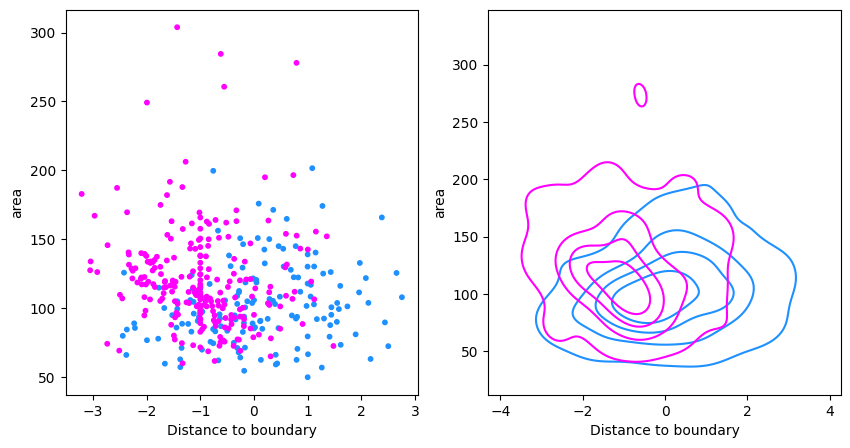

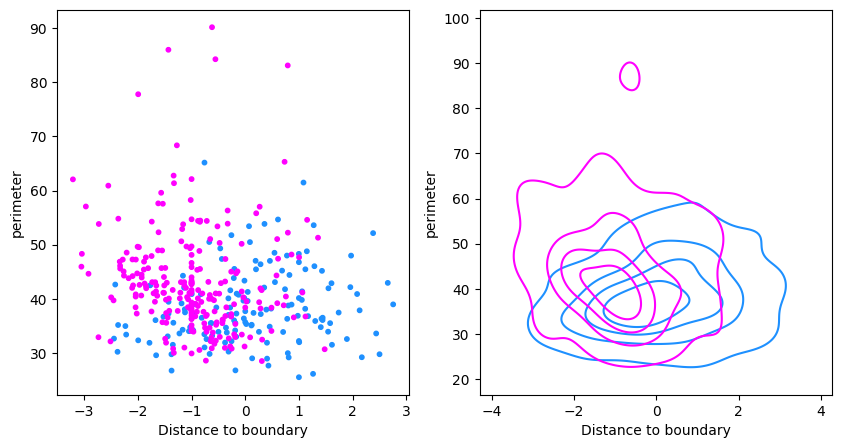

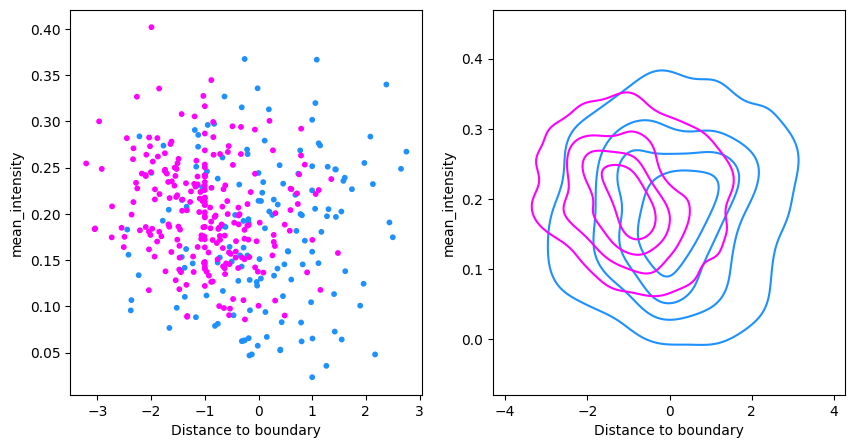

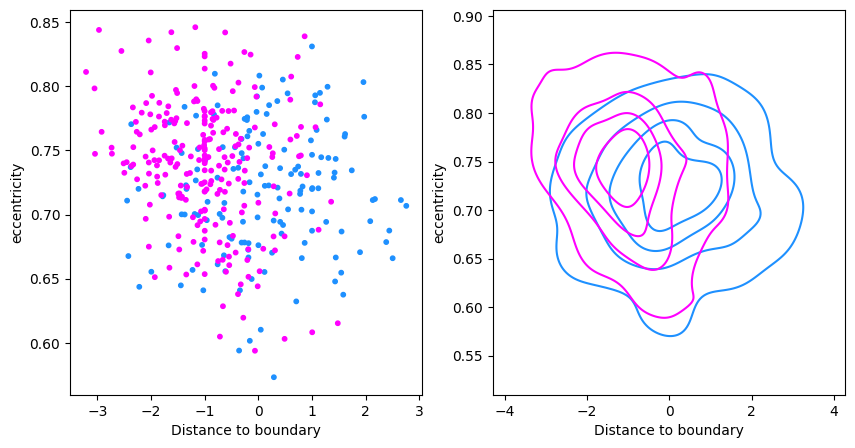

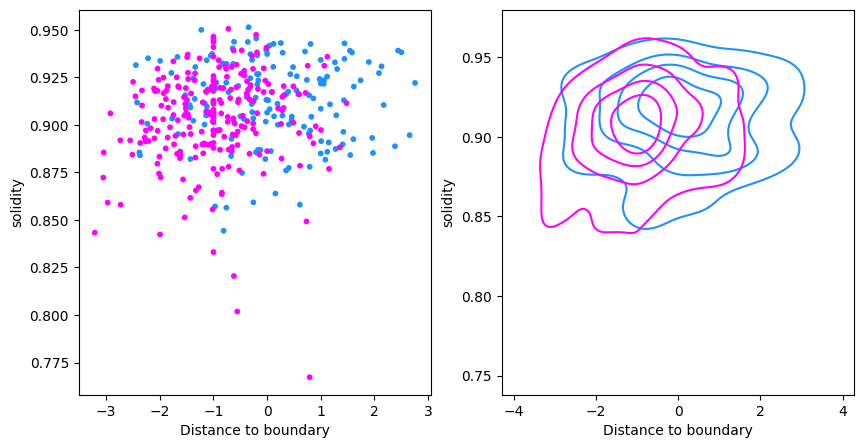

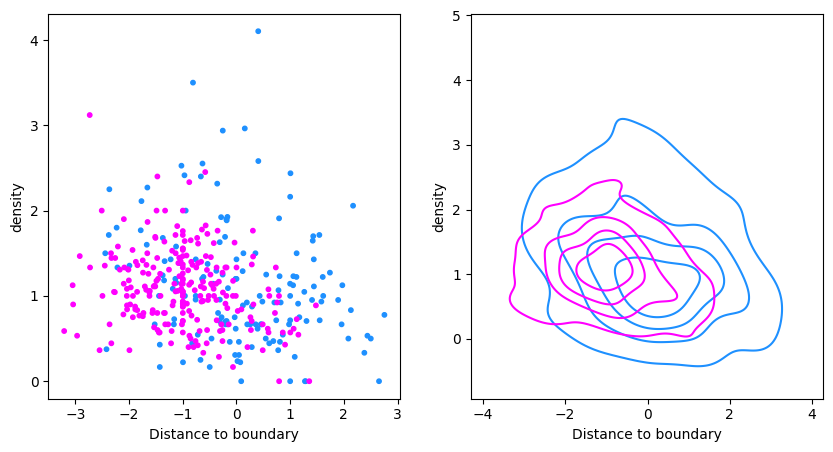

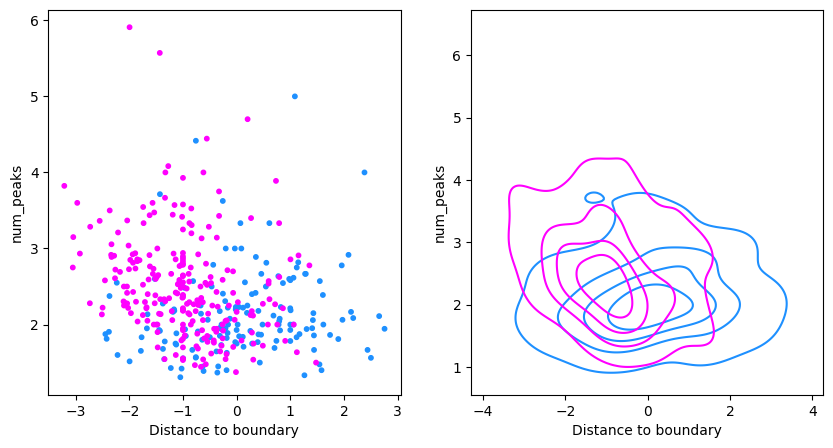

In [27]:
def plot_distance_vs_features(features, labels, distances):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
    unique_labels = np.unique(labels)
    indices_div12 = np.where(labels == unique_labels[0])[0]
    indices_div25 = np.where(labels == unique_labels[-1])[0]
    indices = np.concatenate([indices_div12, indices_div25]) 
    features = features[indices]
    labels = labels[indices]
    distances = distances[indices]
    colors = ["dodgerblue" if l == unique_labels[0] else "fuchsia" for l in labels]
    for feature_idx in range(features.shape[-1] - 1):
        feature_data = features[:, feature_idx]
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))

        axs[0].scatter(distances, feature_data, c=colors, s=10)
        axs[0].set_xlabel("Distance to boundary")
        axs[0].set_ylabel(feature_names[feature_idx])

        dist_c1 = distances[labels == unique_labels[0]].flatten() 
        dist_c2 = distances[labels == unique_labels[-1]].flatten()  
        features_c1 = feature_data[labels == unique_labels[0]].flatten()
        features_c2 = feature_data[labels == unique_labels[-1]].flatten()
        c1_cmap = seaborn.light_palette("dodgerblue", as_cmap=True)
        c2_cmap = seaborn.light_palette("fuchsia", as_cmap=True)
        seaborn.kdeplot(x=dist_c1, y=features_c1, ax=axs[1], color="dodgerblue", levels=5)
        seaborn.kdeplot(x=dist_c2, y=features_c2, ax=axs[1], color="fuchsia", levels=5)
        axs[1].set_xlabel("Distance to boundary")
        axs[1].set_ylabel(feature_names[feature_idx])
        plt.show()
        
plot_distance_vs_features(train_real_features, train_real_labels, train_real_distances)

### Comparing feature values at DIV endpoints

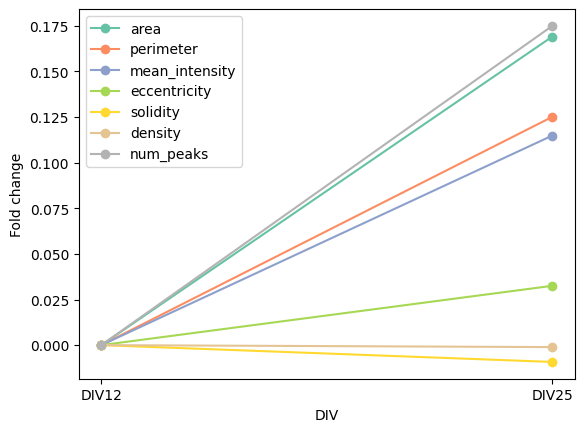

In [28]:
real_features = np.concatenate([train_real_features, valid_real_features], axis=0)
real_labels = np.concatenate([train_real_labels, valid_real_labels], axis=0)

def plot_endpoints(features, labels):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_features = features.shape[1]
    
   
    ordered_data = []
    unique_labels = np.unique(labels)
    for label in [unique_labels[0], unique_labels[-1]]:
        indices = np.where(labels == label)[0]
        ordered_data.append(features[indices])
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = [d[:, feature_idx] for d in ordered_data]

        mean_feature_data = np.array([np.mean(d) for d in feature_data])
        std_feature_data = np.array([np.std(d) for d in feature_data])
        foldchange_feature_data = (mean_feature_data - mean_feature_data[0]) / mean_feature_data[0]
       
        #std_feature_data = np.array([np.std(d) for d in feature_data])
        ax.plot(foldchange_feature_data, c=cmap(feature_idx), label=feature_names[feature_idx], marker="o")
        # ax.fill_between(np.arange(len(foldchange_feature_data)), foldchange_feature_data - foldchange_std_feature_data, foldchange_feature_data + foldchange_std_feature_data, color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    ax.set_ylabel("Fold change")
    ax.set_xlabel("DIV")
    ax.set_xticks(np.arange(2))
    ax.set_xticklabels(["DIV12", "DIV25"])
    # ax.set_yscale("log")
    plt.show()

plot_endpoints(real_features, real_labels)

### Computing average feature values at every DIV

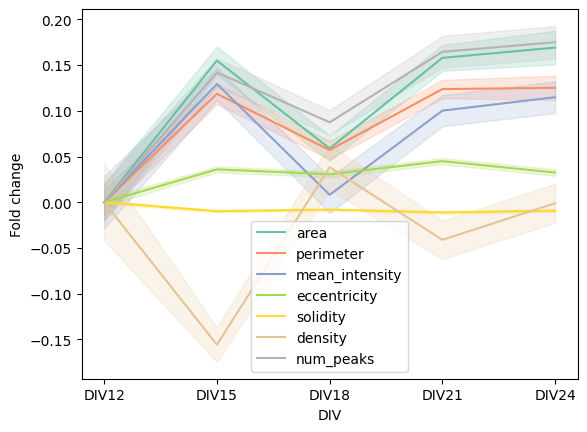

In [ ]:


def plot_real_feature_averages(features, labels):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_features = features.shape[1]
    
   
    ordered_data = []
    for label in np.unique(labels):
        indices = np.where(labels == label)[0]
        ordered_data.append(features[indices])
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = [d[:, feature_idx] for d in ordered_data]
        
        baseline_mean = np.mean(feature_data[0])
        
        all_foldchanges = []
        for timepoint_data in feature_data:
            foldchanges_at_timepoint = (timepoint_data - baseline_mean) / baseline_mean
            all_foldchanges.append(foldchanges_at_timepoint)
        
        mean_foldchange = np.array([np.mean(fc) for fc in all_foldchanges])
        std_foldchange = np.array([np.std(fc) for fc in all_foldchanges])
        sem_foldchange = np.array([np.std(fc) / np.sqrt(len(fc)) for fc in all_foldchanges])
        
        ax.plot(mean_foldchange, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(len(mean_foldchange)), 
                        mean_foldchange - sem_foldchange, 
                        mean_foldchange + sem_foldchange, 
                        color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    ax.set_ylabel("Fold change")
    ax.set_xlabel("DIV")
    ax.set_xticks(np.arange(len(mean_foldchange)))
    ax.set_xticklabels(["DIV12", "DIV15", "DIV18", "DIV21", "DIV24"])
    plt.show()

    

plot_real_feature_averages(real_features, real_labels)

In [31]:
def bootstrap_real_trajectories(features, labels, n=1000):
    out = []
    for _ in trange(n):
        temp = []
        for label in np.unique(labels):
            indices = np.where(labels == label)[0]
            sample_features = features[indices]
            no_good = True 
            while no_good:
                bootstrap_sample = sample_features[np.random.randint(0, len(sample_features))]
                no_good = bootstrap_sample[5] == 0
            temp.append(bootstrap_sample)
        temp = np.array(temp)
        out.append(temp)
    out = np.array(out)
    return out



100%|██████████| 100/100 [00:00<00:00, 14050.33it/s]


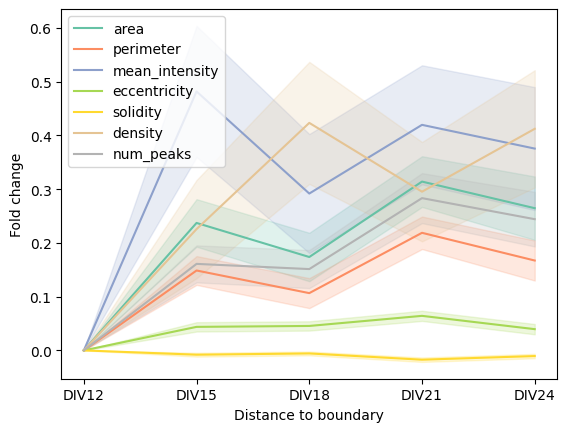

In [40]:
def plot_real_trajectories(features: np.ndarray, labels: np.ndarray, n: int = 1):
    bootstrap_trajectories = bootstrap_real_trajectories(features, labels, n=100)
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_trajectories, num_timesteps, num_features = bootstrap_trajectories.shape 
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = bootstrap_trajectories[:, :, feature_idx]
        feature_data = (feature_data - feature_data[:, 0:1]) / feature_data[:, 0:1]
        
        mean = np.mean(feature_data, axis=0)
        std_err = np.std(feature_data, axis=0)
        sem_err = np.std(feature_data, axis=0) / np.sqrt(len(feature_data))
        cid, ciu = np.percentile(feature_data, 10.0, axis=0), np.percentile(feature_data, 90.0, axis=0)
        
        ax.plot(mean, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(num_timesteps), mean - sem_err, mean + sem_err, color=cmap(feature_idx), alpha=0.2)
        
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel("Fold change")
        ax.set_xticks(np.arange(num_timesteps))
        ax.set_xticklabels(["DIV12", "DIV15", "DIV18", "DIV21", "DIV24"])
    ax.legend()
    plt.show()

plot_real_trajectories(real_features, real_labels, n=1)